In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier


In [2]:
file_path = r"C:\Users\Rohit Dhiman\Downloads\AccidentsBig.csv"
df = pd.read_csv(file_path)
df.head()


C:\Users\Rohit Dhiman\AppData\Local\Temp\ipykernel_14508\304544223.py:2: DtypeWarning: Columns (8,10,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Accident_Index,longitude,latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Time,Local_Authority_(District),...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Date
0,1.0,78.610393,14.724026,1.0,2.0,1.0,1.0,3.0,17:42,12.0,...,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,E01002849,04-01-2018
1,2.0,78.534042,14.762353,1.0,3.0,1.0,1.0,4.0,17:36,12.0,...,5.0,4.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002909,05-01-2018
2,3.0,78.470877,14.745606,1.0,3.0,2.0,1.0,5.0,00:15,12.0,...,0.0,4.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002857,06-01-2018
3,4.0,78.557994,14.667128,1.0,3.0,1.0,1.0,6.0,10:35,12.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002840,07-01-2018
4,5.0,78.576431,14.703443,1.0,3.0,1.0,1.0,2.0,21:13,12.0,...,0.0,7.0,1.0,2.0,0.0,0.0,1.0,1.0,E01002863,10-01-2018


In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Drop rows where target is missing
df = df.dropna(subset=["Accident_Severity"])

# Fill missing values in important categorical columns
fill_cols = [
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Road_Type",
    "Urban_or_Rural_Area"
]

for col in fill_cols:
    df[col] = df[col].fillna("Unknown")

# Convert Time column (if needed)
df["Time"] = df["Time"].fillna("00:00")


In [5]:
features = [
    "Number_of_Vehicles",
    "Number_of_Casualties",
    "Day_of_Week",
    "Speed_limit",
    "Road_Type",
    "Light_Conditions",
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Urban_or_Rural_Area",
    "Did_Police_Officer_Attend_Scene_of_Accident"
]

X = df[features]
y = df["Accident_Severity"]


In [6]:
label_encoders = {}
X = X.copy()

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       random_state=42)

Accuracy: 0.6799166666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.04      0.20      0.06       138
           1       0.19      0.37      0.25      1432
           2       0.91      0.73      0.81     10430

    accuracy                           0.68     12000
   macro avg       0.38      0.43      0.37     12000
weighted avg       0.81      0.68      0.73     12000



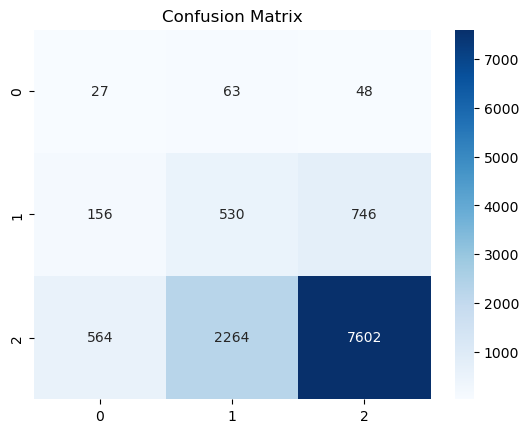

In [9]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [18]:
# Correct numeric sample (no strings)
sample = {
    "Number_of_Vehicles": 1,
    "Number_of_Casualties": 1,
    "Day_of_Week": 2,  # Monday = 2
    "Speed_limit": 50,
    "Road_Type": 6,  # Single carriageway
    "Light_Conditions": 1,  # Daylight
    "Weather_Conditions": 1,  # Fine, no high winds
    "Road_Surface_Conditions": 1,  # Dry
    "Urban_or_Rural_Area": 1,  # 1 = Urban
    "Did_Police_Officer_Attend_Scene_of_Accident": 1  # Yes
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample])

# Predict
pred = rf.predict(sample_df)
severity = target_encoder.inverse_transform(pred)

print("Predicted Accident Severity:", severity[0])


Predicted Accident Severity: 3.0


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

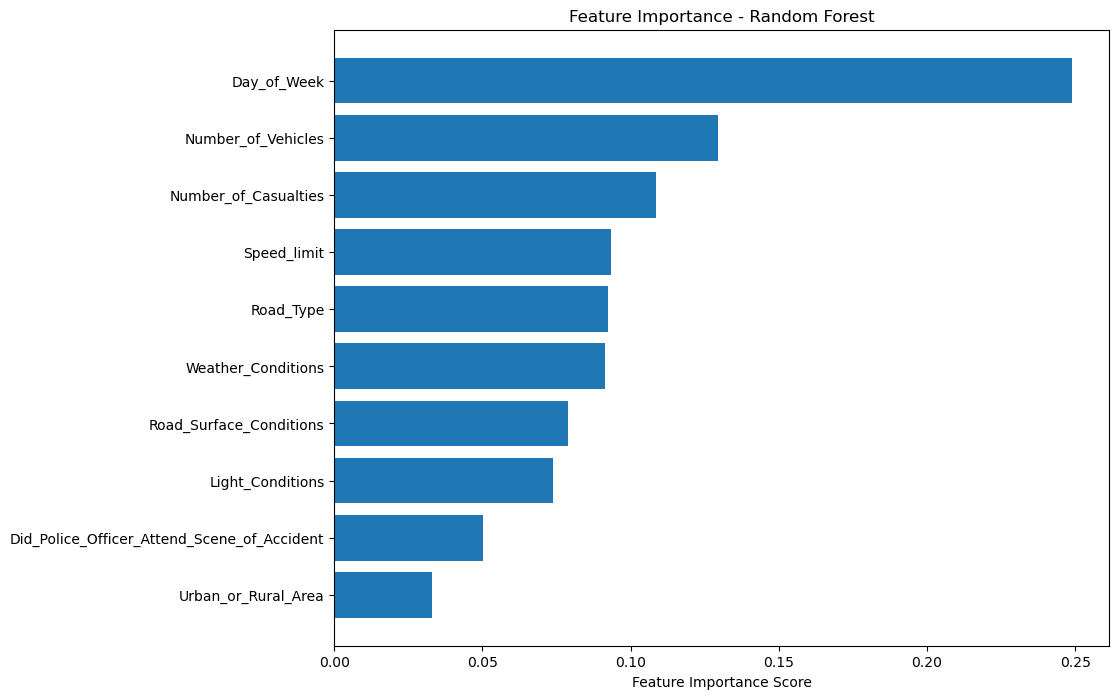

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns

# Sort by importance
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance Score")
plt.title("Feature Importance - Random Forest")
plt.show()
